In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [7]:
data = load_breast_cancer()
print(type(data))
print(dir(data))

<class 'sklearn.utils._bunch.Bunch'>
['DESCR', 'data', 'data_module', 'feature_names', 'filename', 'frame', 'target', 'target_names']


In [8]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [9]:
X = data.data
# print(X)

y = data.target
# print(y)

print(X.shape)  #(569, 30) 데이터 개수, 열
print(len(y))   #569 데이터 569개

(569, 30)
569


In [15]:
# 데이터를 학습용과 테스트용으로 분리/데이터 분할(학습 80%, 테스트 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, y_train.shape)     #(455, 30) (455,)
print(X_test.shape, y_test.shape)       #(114, 30) (114,)


(455, 30) (455,)
(114, 30) (114,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [18]:
# [해결방법]
# HTML 다이어그램 출력 기능을 끄고 텍스트로 표시

# UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence
import platform
import sklearn
print(platform.system())
if platform.system()=='Windows':
    sklearn.set_config(display='text')

# 모델 학습(로지스틱 회귀)
model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
# print(dir(model))

Windows


LogisticRegression(max_iter=10000)

In [19]:
# 예측 (클래스 예측 및 확률 예측)
y_pred = model.predict(X_test)
print(y_pred)       # 에측 결과 
print()

# print(y_pred==y_test)
print(pd.Series(y_pred==y_test).unique())
print(pd.Series(y_pred==y_test).value_counts())
print()

y_prob = model.predict_proba(X_test)
print(y_prob)

[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 1 0 1 1 1 1 1 1 0
 1 0 1 1 0 1 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 0 0 1 1 1 0 0 1 1 0 0 1 0
 1 1 1 1 1 1 0 1 1 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 1 0 0 1 0 0 1 1 1 0 1 1 0
 1 0 0]

[ True False]
True     109
False      5
Name: count, dtype: int64

[[1.21238266e-01 8.78761734e-01]
 [9.99999970e-01 3.03624981e-08]
 [9.98405090e-01 1.59490988e-03]
 [1.21353825e-03 9.98786462e-01]
 [1.39796565e-04 9.99860203e-01]
 [1.00000000e+00 1.94458720e-10]
 [1.00000000e+00 6.09483521e-11]
 [9.80773102e-01 1.92268979e-02]
 [1.58520339e-02 9.84147966e-01]
 [5.63029459e-03 9.94369705e-01]
 [7.04321239e-02 9.29567876e-01]
 [9.99193285e-01 8.06714616e-04]
 [1.10171295e-02 9.88982871e-01]
 [8.24174930e-01 1.75825070e-01]
 [7.79253365e-04 9.99220747e-01]
 [9.98272428e-01 1.72757217e-03]
 [1.18193344e-03 9.98818067e-01]
 [1.18481436e-05 9.99988152e-01]
 [5.99658938e-07 9.99999400e-01]
 [9.99999288e-01 7.11997904e-07]
 [1.71640882e-01 8.28359118e-01]
 [7.63

In [20]:
# 출력 : 혼합행렬
cm = confusion_matrix(y_test, y_pred)       #정답, 예측값
print(cm)


'''
음성: 암, 양성: 정상
            예측
        [음성0][양성1] 
실[음성0]  [[39  4]     tn fp                   
제[양성1]  [ 1 70]]`    fb  tp
'''

[[39  4]
 [ 1 70]]


'\n음성: 암, 양성: 정상\n            예측\n        [음성0][양성1] \n실[음성0]  [[39  4]     tn fp                   \n제[양성1]  [ 1 70]]`    fb  tp\n'

In [21]:
# 평가지표 계산
acc = accuracy_score(y_test, y_pred)    # (정답, 예측)
prec = precision_score(y_test, y_pred)  #positive 예측에서 진짜 positive인 경우
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print('평가지표')
print(f'Accuracy:: {acc}')
print(f'Pricision: {prec}')
print(f'Recall: {rec}')
print(f'F1 Score: {f1}')

평가지표
Accuracy:: 0.956140350877193
Pricision: 0.9459459459459459
Recall: 0.9859154929577465
F1 Score: 0.9655172413793104


# 데이터가 불균형일 때 발생되는 문제
불균형한 이진 분류로 만들기 위해 숫자 '7'만 True 나머지 숫자는 False로 설정

- 마찬가지로 fit은 아무것도 하지 않음
- predict에서는 무조건 0을 반환함
- 모든 예측을 다 0으로 하는 것! (모두 7이 아닌 다른 숫자라고 예측)
- 당연히 모델로서 말이 안 되는데 이것의 정확도를 측정

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

In [ ]:
# MyfakeClassifier 알고리즘 정의
class MyFakeClassifier(BaseEstimator):
    def fit(self,X,y):
        pass

    # 입력값으로 들어오는 X 데이터 셋의 크기만큼 모두 0값으로 만들어서 반환
    def predict(self,X):
        return np.zeros( (len(X), 1) , dtype=bool)      # 열 크기가 1


#사이킷런의 내장 데이터 셋인 olad_digits()를 이요하여 MNIST 데이터 로딩
digits = load_digits()

print(digits.data)
print('### digits.data.shape:', digits.data.shape)
print(digits.target)
print('### digits.target.shape:', digits.target.shape)


[[ 0.  0.  5. ...  0.  0.  0.]
 [ 0.  0.  0. ... 10.  0.  0.]
 [ 0.  0.  0. ... 16.  9.  0.]
 ...
 [ 0.  0.  1. ...  6.  0.  0.]
 [ 0.  0.  2. ... 12.  0.  0.]
 [ 0.  0. 10. ... 12.  1.  0.]]
### digits.data.shape: (1797, 64)
[0 1 2 ... 8 9 8]
### digits.target.shape: (1797,)


In [ ]:
print(digits.target)
# 숫자가 7인 경우 : True , 나머지 : false
# 이를 1과 0으로 변환하기 위해서 astype(int)로 한 것이다.
y = (digits.target==7).astype(int)      #7이면 1 나머지는0으로 데이터 만을어짐

print(len(y))       #1797

print(pd.Series(y).value_counts()) 
'''
0    1618
1     179'''

X_train, X_test, y_train, y_test = train_test_split(digits.data, y, random_state=11)
print(pd.Series(y_train).value_counts())
'''
0    1213
1     134'''
print(pd.Series(y_test).value_counts())
'''
0    405
1     45'''

[0 1 2 ... 8 9 8]
1797
0    1618
1     179
Name: count, dtype: int64
0    1213
1     134
Name: count, dtype: int64
0    405
1     45
Name: count, dtype: int64


'\n0    405\n1     45'

In [61]:
fakeclf = MyFakeClassifier()
fakeclf.fit(X_train, y_train)

fakepred = fakeclf.predict(X_test)
print('모든 예측을 0으로 하여도 정확도는 : {:.3f}'.format(accuracy_score(y_test, fakepred)))


cf = confusion_matrix(y_test, fakepred)
print(f'Accuracy: {cf}')

f1 = f1_score(y_test, fakepred)
print(f'f1_socre: {f1}')

prec = precision_score(y_test, fakepred)
print(f'Precision: {prec}')

모든 예측을 0으로 하여도 정확도는 : 0.900
Accuracy: [[405   0]
 [ 45   0]]
f1_socre: 0.0
Precision: 0.0


c:\sk-encoa\data-collection-workspace\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


0. average='binary' (default)
   - positive label을 1로 간주하고 계산한다.
   - y_true에 0과 1 두 개 클래스만 있어야 한다.

1. average=None (클래스별 성능 개별 출력)

| 클래스               | Precision | Recall | F1-score | Support |
| ----------------- | --------- | ------ | -------- | ------- |
| **0 (malignant)** | 0.97      | 0.91   | 0.94     | 43      |
| **1 (benign)**    | 0.95      | 0.99   | 0.97     | 71      |

- 각 클래스별로 정밀도, 재현율, F1-score를 개별적으로 계산하여 보여준다.
- 모델이 클래스 0 (악성 종양)을 상대적으로 덜 잘 맞추고 있다는 것을 파악할 수 있다.

In [26]:
# average : Literal['micro', 'macro', 'samples', 'weighted', 'binary'] | None
# # 평가지표 계산
# acc = accuracy_score(y_test, y_pred)    # (정답, 예측)
# prec = precision_score(y_test, y_pred)  # positive 예측에서 진짜 positive 인 경우
# rec = recall_score(y_test, y_pred)
# f1 = f1_score(y_test, y_pred)


# 1.average = None (클래스별 개별 출력)
print('평가 지표')
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print()


# 2. average='micro'
print("average='micro'")
print("Precision:", precision_score(y_test, y_pred, average='micro'))
print("Recall   :", recall_score(y_test, y_pred, average='micro'))
print("F1 Score :", f1_score(y_test, y_pred, average='micro'))
print()

# 3. average='macro'
print("average='macro'")
print("Precision:", precision_score(y_test, y_pred, average='macro'))
print("Recall   :", recall_score(y_test, y_pred, average='macro'))
print("F1 Score :", f1_score(y_test, y_pred, average='macro'))
print()

# 4. average='weighted'
print("average='weighted'")
print("Precision:", precision_score(y_test, y_pred, average='weighted'))
print("Recall   :", recall_score(y_test, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_test, y_pred, average='weighted'))
print()

평가 지표
Precision: 0.9459459459459459
Recall   : 0.9859154929577465
F1 Score : 0.9655172413793104

average='micro'
Precision: 0.956140350877193
Recall   : 0.956140350877193
F1 Score : 0.956140350877193

average='macro'
Precision: 0.960472972972973
Recall   : 0.9464461185718964
F1 Score : 0.9526381387619444

average='weighted'
Precision: 0.9569049312470365
Recall   : 0.956140350877193
F1 Score : 0.9558014271241044



2. average='micro' (전체 기준 - 샘플 단위의 합)  
- micro 평균은 모든 TP, FP, FN을 전 클래스 기준으로 합산한 뒤 계산한다.
- 이 경우 정확도(Accuracy) = Precision = Recall = F1-score가 된다.
- 총 정답 수: TP(전체 맞춤 수) = 0 클래스에서 39개 + 1 클래스에서 70개 = 109
- 전체 샘플 수: 114
- 따라서:    Accuracy = Precision = Recall = F1 = 109 / 114 ≈ 0.9561  

3. average='macro' (단순 평균)  
- 클래스별 점수를 동일한 비중으로 평균함
  Macro Precision = (0.97 + 0.95) / 2 = 0.96  
  Macro Recall    = (0.91 + 0.99) / 2 = 0.95  
  Macro F1-score  = (0.94 + 0.97) / 2 = 0.955 ≈ 0.95  

- 클래스 0과 1의 비중이 같다고 가정하고 평균 내기 때문에, 클래스 불균형이 있는 경우에는 왜곡이 있을 수 있다.

4. average='weighted' (샘플 수 기반 가중 평균)  
-  각 클래스의 점수에 해당 클래스의 샘플 개수(Support)를 곱해서 평균
  Weighted Precision = (0.97×43 + 0.95×71) / 114 ≈ 0.958    
  Weighted Recall    = (0.91×43 + 0.99×71) / 114 ≈ 0.961  
  Weighted F1-score  = (0.94×43 + 0.97×71) / 114 ≈ 0.961  

- 실제 출력값은 모두 반올림되어 0.96으로 나옴

- 데이터 불균형을 고려한 평균이므로, 실전에서 가장 신뢰도 있는 지표 중 하나임

5. average 옵션 요약

| 평균 방식      | 설명                    | 특징               | 언제 사용하면 좋은가?                 |
| ---------- | --------------------- |------------ | ---------------------------- |
| `None`     | 클래스별 개별 지표 확인         |  `array` 형태       | 특정 클래스 성능 비교 시               |
| `micro`    | 전체 샘플 기준으로 정밀도/재현율 계산 | 불균형 데이터에 취약      | 다중 클래스, 불균형 무시하고 전체 성능 확인 시  |
| `macro`    | 클래스별 단순 평균            | 클래스 중요도 균일할 때 사용 |클래스 간 균형 평가 시                |
| `weighted` | 클래스별 가중 평균            | 불균형 데이터에 적합      |**불균형 데이터에서의 전체 성능 평가** 시 유리 |


In [27]:
from sklearn.metrics import classification_report


target_names = data.target_names  # ['malignant', 'benign']
print(target_names)

'''
| 용어            | 한글 해석   | 설명                                                                          |
| -------------   | ------- | --------------------------------------------------------------------------- |
| **malignant**   | 악성 (암)  | 빠르게 자라고 전이할 가능성이 높은 종양이나 질병. 보통 **암(Cancer)** 을 뜻함. 치료가 어렵고 생명에 위협이 될 수 있음. |
| **benign**      | 양성  (비암성) | 성장하긴 하지만 전이하지 않으며 비교적 **위험하지 않은 상태**. 수술 등으로 완치 가능한 경우가 많음.                 |

- malignant: 악성 종양 (암) → 0 또는 Negative Class
- benign: 양성 종양 (비암성) → 1 또는 Positive Class
'''



# 0. 전체 classification_report
print("Classification Report")
# target_names옵션을 설정하지 않으면 0과 1로 표시된다.
print(classification_report(y_test, y_pred))
print("Classification Report")
print(classification_report(y_test, y_pred, target_names=target_names))

['malignant' 'benign']
Classification Report
              precision    recall  f1-score   support

           0       0.97      0.91      0.94        43
           1       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Classification Report
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



# 1. LogisticRegression  분류 알고리즘

LogisticRegression( )알고리즘의 penalty='l2', *, dual=False, tol=0.0001, C=1.0, fit_intercept=True, intercept_scaling=1, class_weight=None, random_state=None, solver='lbfgs', max_iter=100, multi_class='deprecated', verbose=0, warm_start=False, n_jobs=None, l1_ratio=None  


1. **penalty:**  
정규화 방법을 지정한다. 'l2'는 L2 정규화를 의미하며, 이는 가중치의 제곱합을 최소화하여 과적합을 방지하는 데 도움을 준다. 'l1'을 선택하면 L1 정규화를 사용하여 일부 가중치를 0으로 만들 수 있다. 'elasticnet'을 선택하면 L1과 L2 정규화를 혼합하여 사용할 수 있다.  
**2. dual:**  
이진 분류 문제에서 이중 문제를 해결할지를 결정한다. True로 설정하면 이중 문제를 해결하고, False로 설정하면 원래의 문제를 해결한다. 일반적으로 이진 분류에서는 False로 설정하는 것이 더 효율적이다.  
**3. tol:**  
수렴 기준을 설정합니다. 알고리즘이 수렴했다고 판단하는 기준으로, 기본값은 0.0001이다. 이 값이 작을수록 더 정밀한 수렴을 요구한다.  
**4. C:**  
정규화 강도를 조절하는 하이퍼파라미터이다. 값이 작을수록 정규화가 강해지고, 값이 클수록 정규화가 약해진다. 기본값은 1.0이다.  
**5. fit_intercept:**  
절편(intercept)을 모델에 포함할지를 결정한다. True로 설정하면 절편을 포함하고, False로 설정하면 절편을 포함하지 않는다. 기본값은 True이다.  
**6. intercept_scaling:**  
다중 클래스 문제에서 절편을 조정하는 데 사용된다. 기본값은 1이며, 이 값은 절편의 스케일을 조정하는 데 사용된다.  
**7. class_weight:**  
클래스의 가중치를 설정한다. None으로 설정하면 모든 클래스의 가중치가 동일하게 설정됩니다. 클래스 불균형이 있는 경우, 특정 클래스에 더 높은 가중치를 부여하여 모델이 해당 클래스를 더 잘 학습하도록 할 수 있다.
**8. random_state:**  
난수 생성기의 시드를 설정합니다. 동일한 시드를 사용하면 동일한 결과를 재현할 수 있다. 기본값은 None이다.  
**9. solver:**  
최적화 알고리즘을 선택한다. 'lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga' 중 하나를 선택할 수 있다. 각 솔버는 서로 다른 특성과 성능을 가지므로 데이터셋에 따라 적절한 솔버를 선택하는 것이 중요하다.  
**10. max_iter:**      
알고리즘의 최대 반복 횟수를 설정한다. 기본값은 100이며, 이 값에 도달하기 전에 수렴하면 알고리즘이 종료된다.  
**11. multi_class:**  
다중 클래스 문제에서의 처리 방법을 설정한다. 'deprecated'는 더 이상 사용되지 않는 옵션이며, 대신 'ovr' (One-vs-Rest) 또는 'multinomial'을 사용할 수 있다.  
**12. verbose:**  
출력의 상세 정도를 설정한다. 0이면 출력이 없고, 1 이상의 값으로 설정하면 더 많은 정보가 출력된다.  
**13. warm_start:**  
이전에 학습한 모델을 재사용할지를 결정한다. True로 설정하면 이전 모델의 가중치를 초기값으로 사용하여 학습을 계속할 수 있다.  
**14. n_jobs:**  
병렬 처리를 위한 작업 수를 설정한다. None으로 설정하면 기본값이 사용되며, -1로 설정하면 모든 CPU 코어를 사용한다.  
**15. l1_ratio:**  
L1과 L2 정규화의 비율을 설정한다. 'elasticnet'을 사용할 때만 의미가 있으며, 기본값은 None이다.

### 타이타닉 탑승자 데이터
| 컬럼명              | 설명                                                        |
| ---------------- | --------------------------------------------------------- |
| **survived**     | 생존 여부 (0 = 사망, 1 = 생존)                                    |
| **pclass**       | 선실 등급 (1 = 1등석, 2 = 2등석, 3 = 3등석)                         |
| **sex**          | 성별 ('male', 'female')                                     |
| **age**          | 나이                                                        |
| **sibsp**        | 함께 탑승한 형제/배우자 수 (siblings/spouses)                        |
| **parch**        | 함께 탑승한 부모/자녀 수 (parents/children)                         |
| **fare**         | 승객 요금                                                     |
| **embarked**     | 탑승 항구 코드 (C = Cherbourg, Q = Queenstown, S = Southampton) |
| **class**        | `pclass`와 동일하지만 문자열로 표시 ('First', 'Second', 'Third')      |
| **who**          | 승객 구분 ('man', 'woman', 'child')                           |
| **adult\_male**  | 성인 남성 여부 (True/False)                                     |
| **deck**         | 객실이 위치한 갑판 (A\~G 등, 일부 결측값 존재)                            |
| **embark\_town** | 탑승 도시명 (예: 'Cherbourg', 'Southampton')                    |
| **alive**        | 생존 여부 문자열 ('yes' 또는 'no')                                 |
| **alone**        | 혼자 탑승 여부 (True/False)                                     |

※ survived와 alive은 같은 컬럼이므로 alive제외하고 훈련해야함

In [30]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix,  classification_report

In [32]:
titanic = sns.load_dataset('titanic')
print(titanic.columns)
print(titanic.info())
print(titanic.head(2))

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town',
       'alive', 'alone'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null  

In [33]:
titanic.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [35]:
titanic.isnull().sum(axis=0)

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [43]:
titanic.fillna({'age':titanic['age'].mean(), 'embarked':'S'}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [40]:
titanic['age'].isnull().sum()

np.int64(0)

In [42]:
titanic['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [41]:
titanic['embarked'].isnull().sum()

np.int64(2)

In [44]:
titanic.fillna({'embarked': 'N'}, inplace=True)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [45]:
titanic['deck'] = titanic['deck'].cat.add_categories('N')
titanic.fillna({'deck': 'N'}, inplace=True)
titanic['deck'].isnull().sum()

np.int64(0)

In [46]:
titanic['deck'].value_counts()

deck
N    688
C     59
B     47
D     33
E     32
A     15
F     13
G      4
Name: count, dtype: int64

In [50]:
titanic.fillna({'embark_town': 'N'}, inplace=True)
titanic['embark_town'].isnull().sum()

np.int64(0)

In [47]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          891 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     891 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         891 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [48]:
titanic['sex'].value_counts()

sex
male      577
female    314
Name: count, dtype: int64

In [49]:
titanic['survived'].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

In [51]:
print(dir(titanic))

['T', '_AXIS_LEN', '_AXIS_ORDERS', '_AXIS_TO_AXIS_NUMBER', '_HANDLED_TYPES', '__abs__', '__add__', '__and__', '__annotations__', '__array__', '__array_priority__', '__array_ufunc__', '__arrow_c_stream__', '__bool__', '__class__', '__contains__', '__copy__', '__dataframe__', '__deepcopy__', '__delattr__', '__delitem__', '__dict__', '__dir__', '__divmod__', '__doc__', '__eq__', '__finalize__', '__floordiv__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getitem__', '__getstate__', '__gt__', '__hash__', '__iadd__', '__iand__', '__ifloordiv__', '__imod__', '__imul__', '__init__', '__init_subclass__', '__invert__', '__ior__', '__ipow__', '__isub__', '__iter__', '__itruediv__', '__ixor__', '__le__', '__len__', '__lt__', '__matmul__', '__mod__', '__module__', '__mul__', '__ne__', '__neg__', '__new__', '__or__', '__pandas_priority__', '__pos__', '__pow__', '__radd__', '__rand__', '__rdivmod__', '__reduce__', '__reduce_ex__', '__repr__', '__rfloordiv__', '__rmatmul__', '__rmod_

In [59]:
# 성별 생존여부
titanic.groupby(['sex','survived']).value_counts()
# titanic.groupby(['sex', 'survived'])[ 'survived' ].count()



sex     survived  pclass  age        sibsp  parch  fare     embarked  class   who    adult_male  deck  embark_town  alive  alone
female  0         3       29.699118  8      2      69.5500  S         Third   woman  False       N     Southampton  no     False    3
                                     3      1      25.4667  S         Third   woman  False       N     Southampton  no     False    3
                                     0      0      8.0500   S         Third   woman  False       N     Southampton  no     True     2
                          14.000000  0      0      7.8542   S         Third   child  False       N     Southampton  no     True     1
                          31.000000  1      0      18.0000  S         Third   woman  False       N     Southampton  no     False    1
                                                                                                                                   ..
male    1         1       26.000000  0      0      30.0000  C      

<Axes: xlabel='sex', ylabel='survived'>

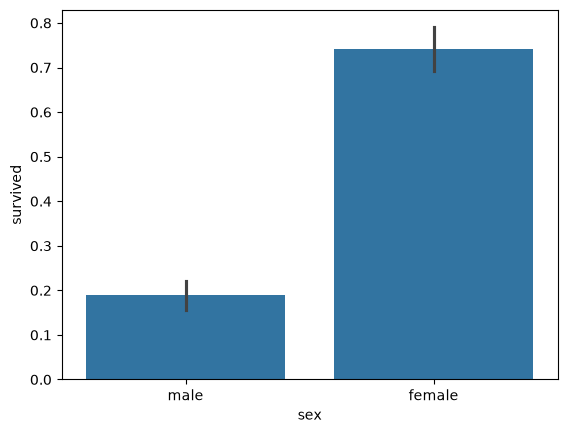

In [60]:
sns.barplot(data=titanic, x='sex', y='survived')

<Axes: xlabel='pclass', ylabel='survived'>

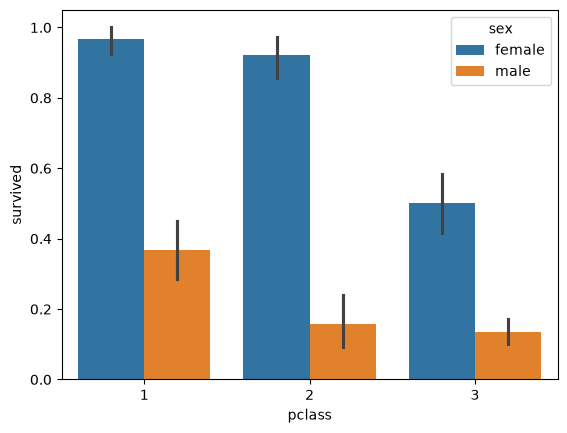

In [62]:
sns.barplot(data=titanic, x='pclass', y='survived', hue='sex')

In [63]:
X_train, X_test, y_train, y_test = train_test_split(titanic.loc[:, ['pclass', 'alone']], titanic['survived'], test_size=0.2, random_state=42)

In [64]:
model = LogisticRegression(max_iter=10000)

In [65]:
import platform

if platform.system()=='Windows':

model.fit(X_train, y_train)

IndentationError: expected an indented block after 'if' statement on line 3 (2530930287.py, line 5)

In [66]:
import platform
import sklearn

if platform.system() == 'Windows':
    sklearn.set_config(display='text')

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [67]:
import platform
import sklearn

if platform.system() == 'Windows':
    sklearn.set_config(display='text')

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)